# Ensemble

- what is ensemble?
- why use it?


---
### What is ensemble?

- average of MLearning models' predictors
  > _public wisdom is better than a single expert_

- methodology
  - bagging, boosting, stacking
  - _random forest_: an ensemble (bagging) of tree models


---  
### How to average?

1. hard voting:
    - predict with majority voting

2. soft voting
    - predict with averaged probability over all the individual classifiers
  
    

---   
### Hard voting example

- Algo1:{1 $\succ$ 2} <br>
- Algo2:{1 $\succ$ 2}  <br>
- Algo3:{1 $\prec$ 2}  <br>
- Algo4:{1 $\succ$ 2}  <br>
       $\Longrightarrow$ select model 1

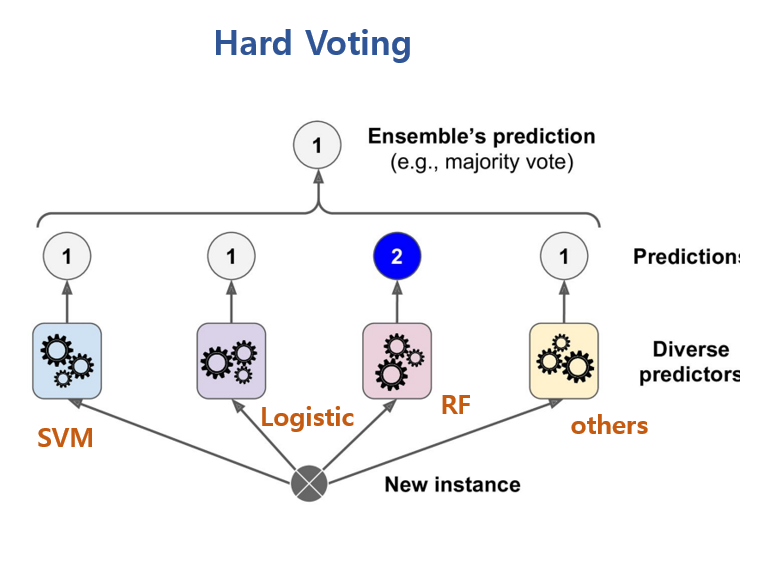

In [ ]:
from IPython.display import Image
Image("G:/python/images/HAR.PNG")

---
### Soft voting example

- Algo1:{P(1)=0.6, P(2)=0.4} <br>
    - Algo2:{P(1)=0.55, P(2)=0.45}  <br>
    - Algo3:{P(1)=0.1, P(2)=0.9}  <br>
    - Algo4:{P(1)=0.51, P(2)=0.49}  <br>    
  $$\Longrightarrow P^{average}(1)=0.44, P^{average}(2)=0.56$$
  <br>
  $$\Longrightarrow \text{select model 2}$$


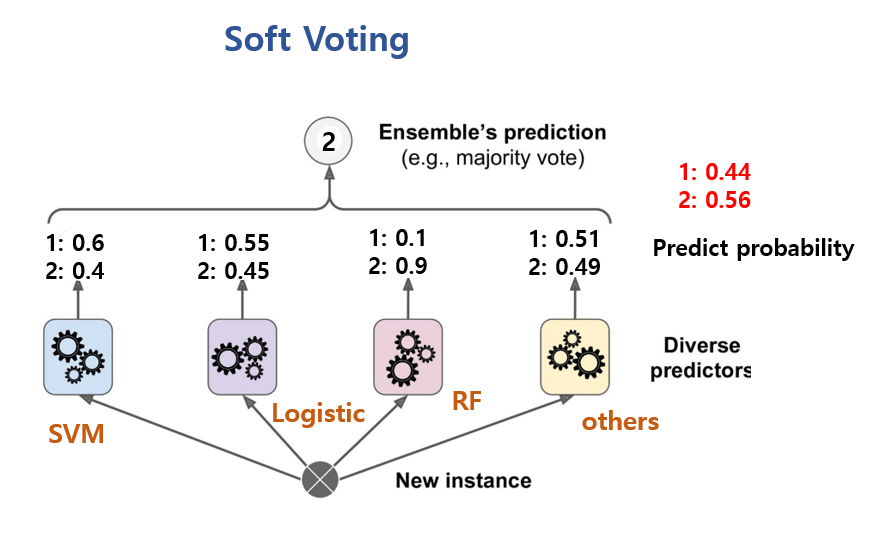

---
### Why average is better than individual voting?

- suppose you have a couple of ML algorithms predicting probabilities with 51% (merely more than random walk)   
<br>
- If doing soft voting, what is the probability of greater than 50% with 1000 prediction?
$$
\begin{align}
P(X \ge 501) &= \sum_{k=501}^{N} {{N}\choose{k}}p^k (1-p)^{n-k} \\
             &= \sum_{k=501}^{1000} {{1000}\choose{k}}(0.51)^k (0.49)^{n-k} \\
             &= 0.726
\end{align}
$$

- for 10000 experiments, the probability is **0.977**

- "you build an ensemble containing 1,000 classifiers that are individually
   correct only 51% of the time (barely better than random guessing).
   If you predict the majority voted class, you can hope for up to 75% accuracy!"
     
    - **pre-codition: if all classfiers are independent**



In [ ]:
### verification of the above

from scipy.stats import binom

n = 1000
p = 0.51
bin_ = binom(n, p)
sum = 0
for i in range(501, 1000):
    sum += bin_.pmf(i)

print(sum)

0.7260985557309101


### Library API: skelarn

```
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
```

# Random Forest

---   
### What is random forest?

- ensemble of tree model with __ramdom featuring__

    - each tree trained only with  a subset of features

 - the forest of randomized decision trees deliver predicted class and final decision is averaged out

 - RF is to overcome decision tree's overfitting problem.

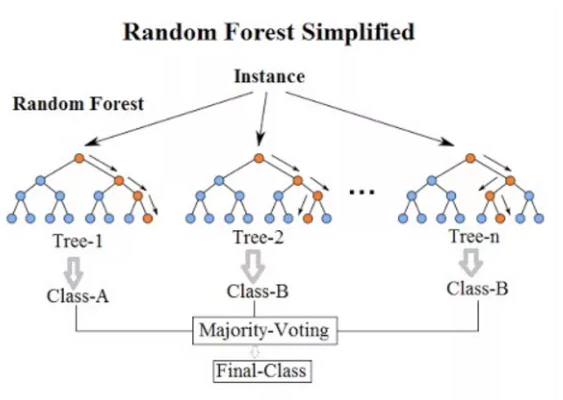

In [ ]:
Image("G:/python/images/RandomForestTree2.PNG")

---
### difference b/w Bagging and Random Forest


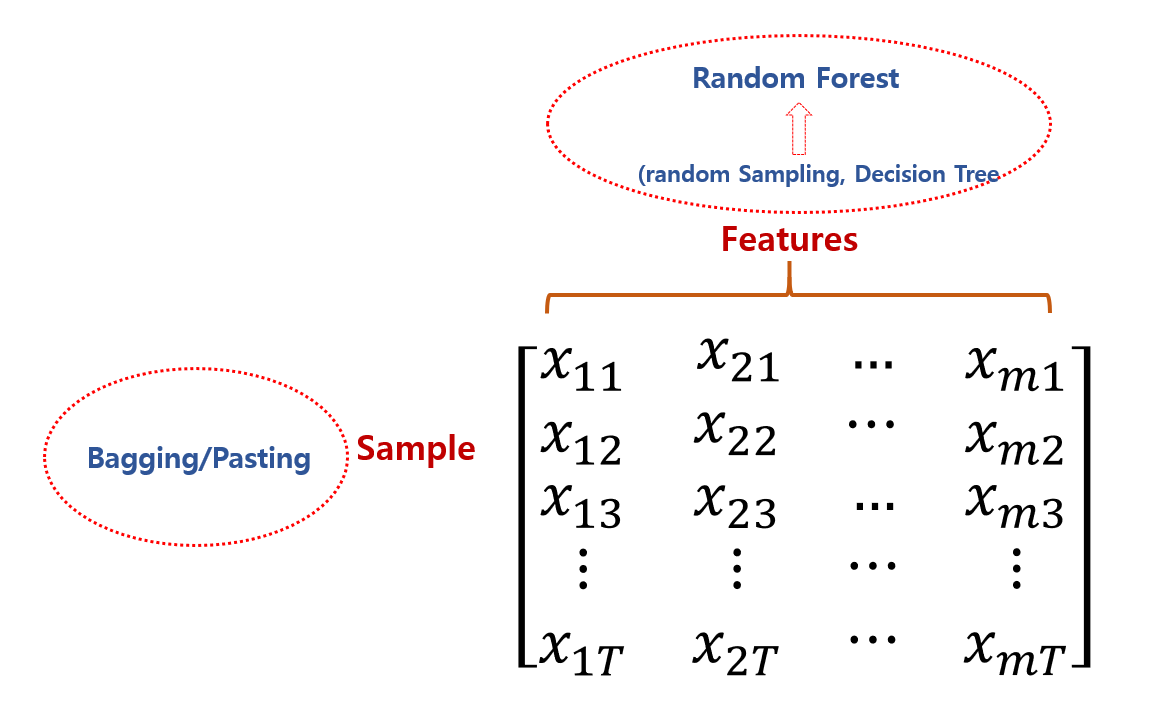

<Figure size 648x648 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import Image
plt.figure(figsize=(9,9))
Image("G:/python/images/RFvsBagging.PNG", width=600, height=200)

## Bagging with decision tree = RF

```BaggingClassifier(base_model=DecisionTreeClassifier())```
```RandomForestClassifier```

## Key hyper-parameters in Ensemble
    `import sklearn  dir(sklearn.ensemble)'
1. Bagging
  - ```base_estimator```
  - ```n_estimators```
  - ```random_state```
  - ```boostrap=True```

2. Random forest
  - ```n_estimators```
  - ```max_features```: fraction of predictors   
  - ```min_samples_leaf```   
  - ```boostrap```
  - ```random_state```   
  

### Random forest in finance

- what is probability of an event?

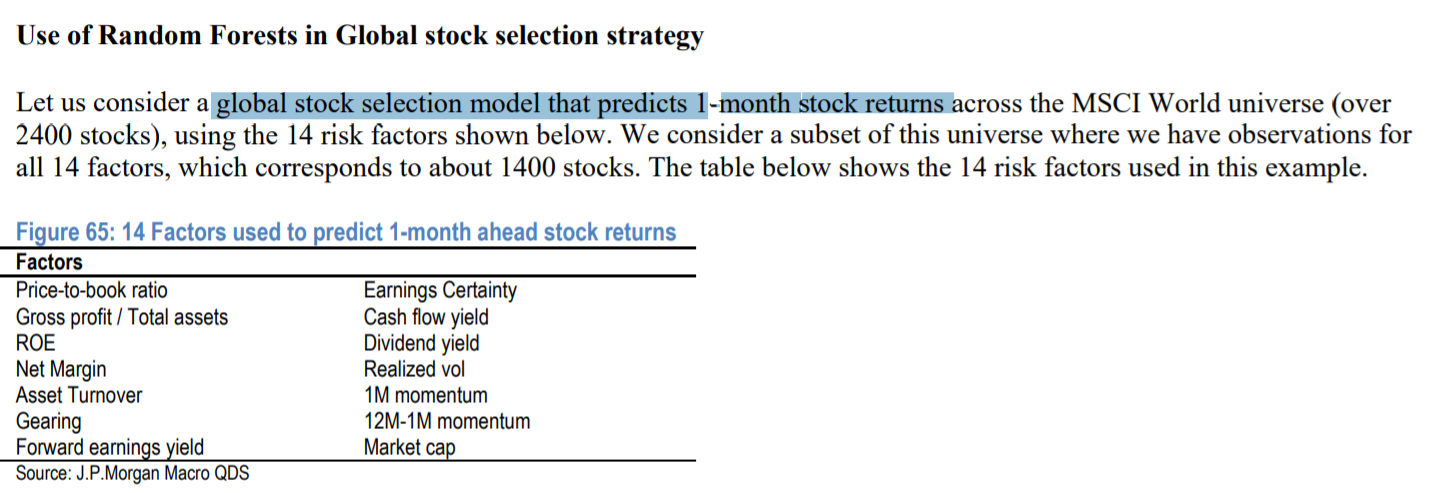

In [ ]:
Image("G:/python/images/JP_RF.PNG")

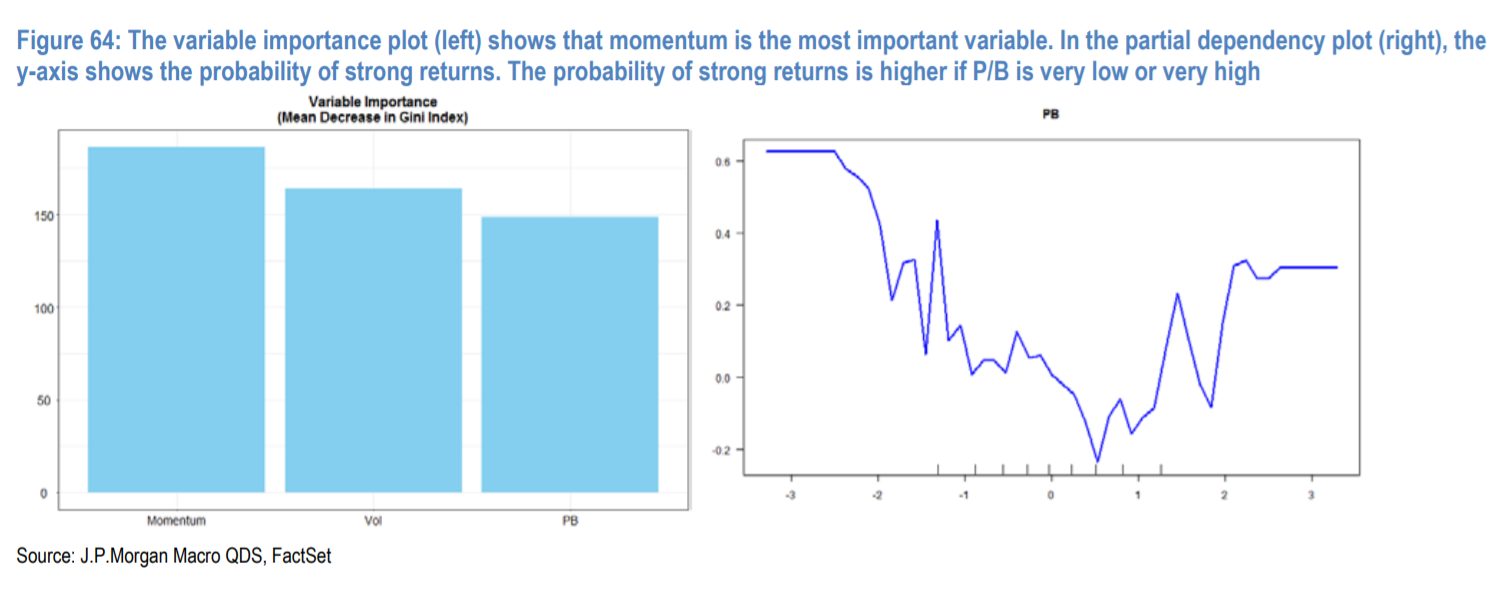

In [ ]:
Image("G:/python/images/JP_rf_example.PNG")

---
# feature importance

- how a feature decrease impurity in a tree?
\begin{aligned}
FI_j = \frac{N_j}{N} \times \Big( G_j -  \frac{N_jR}{N_j}  G_R - \frac{N_jL}{N_j}  G_L\Big)
\end{aligned}
- where
  - j: $j^{th}$ node
  - N: total sample size
  - $N_j$: $j^{th}$ sample size
  - $G_j$: $j^{th}$ impurity
  - $G_R$: right impurity


- __sklearn__: ```clf.feature_importances_```

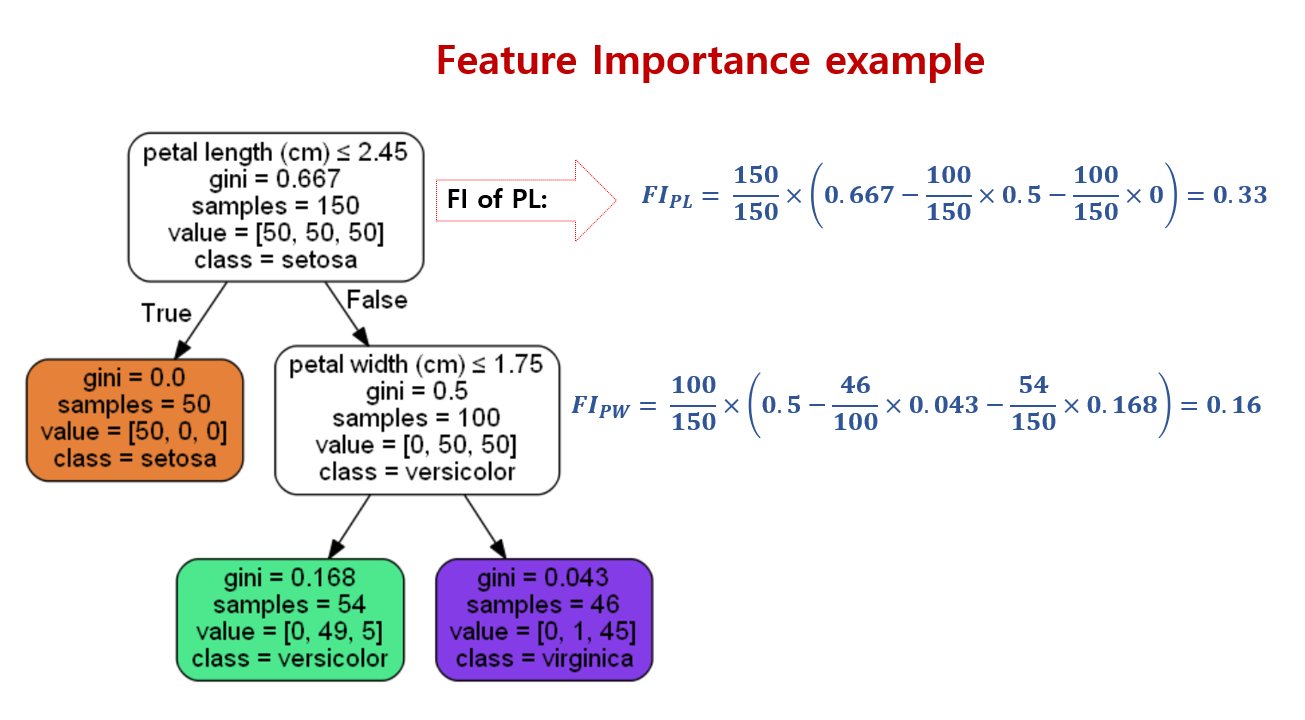

In [ ]:
Image("G:/python/images/FeatureImportancExample.PNG", width=600, height=200)

 ### Select important features in random forest

- want to reduce number of features to enhance interpretability or improve forecasting variance
- procedure
  - model fit with full features and identify important features
  - create new features with important ones  

- __sklearn__:  

```
from sklearn.feature_selection import SelectFromModel
```

- see [empirics notebook](empirics_SelectFromModel.ipynb)

### Empirics: Most ML used example

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn')

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn import metrics
dir(sklearn.metrics)

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
accuracy_score(y_test, clf.predict(X_test))

0.9473684210526315

### Ensemble: Stacking / Blending

- see [stacking/blending notebook](ensemble_stacking_introduction.ipynb)

- see [blending empirics with SamSungEle](empirics_SamSungEle_blender.py)

## Boosting

- see [notebook boosting](boosting_introdu.ipynb)